<img src="https://sfudial.ca/wp-content/uploads/SFU-DIAL-Logo.png" width=40%>&nbsp;&nbsp;&nbsp;&nbsp;<img src="https://www.sfu.ca/content/dam/sfu/images/brand_extension/SFU-Big-Data_Logo.png" width=40%>

# Lab 4.1: Detecting Anomalies with AI

Learn how to use AI-powered tools to detect anomalies in real-world datasets. Explore different anomaly detection techniques and understand when to apply each approach for maximum effectiveness.

**Use the TODOs and prompt your AI like a teammate. Think critically, experiment often, and document your process.**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/gist/git-steb/aefa0f766e56dcbbe0bacdc607fdaa4a/4_1_Detecting_Anomalies_with_AI.ipynb)

## Lab Outline

- **Part 1:** Set up your environment and load datasets
- **Part 2:** Explore traditional anomaly detection methods
- **Part 3:** Apply AI-enhanced anomaly detection
- **Part 4:** Compare approaches and interpret results
- **Deliverable:** Reflection on AI-assisted anomaly detection

## Getting Help from Your AI Assistant

**Why AI assistance matters:** AI tools can help you understand complex anomaly detection algorithms, suggest appropriate techniques for your data, and interpret results effectively. They're particularly valuable for learning when to use different approaches.

**Good prompts:**
- "Help me understand what makes this data point an anomaly"
- "What anomaly detection method would work best for this type of data?"
- "How can I validate that these anomalies are real and not noise?"
- "What would an expert look for when detecting anomalies?"
- "Help me interpret these anomaly scores"
- "How can I reduce false positives in my anomaly detection?"

**Avoid vague prompts like "find anomalies"**

**Pro Tip:** Ask "what would a data scientist look for" and "how should I validate these results" to get more targeted assistance.

## Learning Objectives

By the end of this lab, you will be able to:
- [ ] **Set up and configure** AI-enhanced anomaly detection environments with proper data preprocessing
- [ ] **Compare and contrast** traditional statistical methods vs. AI-powered approaches for anomaly detection
- [ ] **Apply machine learning techniques** (Isolation Forest, DBSCAN, Autoencoders) to detect anomalies in real datasets
- [ ] **Interpret and validate** anomaly detection results to distinguish between real anomalies and noise
- [ ] **Choose appropriate methods** based on data characteristics and business requirements
- [ ] **Build practical skills** for detecting fraud, system failures, and unusual patterns in professional contexts

## Why Anomaly Detection Matters in the Real World

**Anomaly detection is crucial for business success** because it helps identify:
- **Financial fraud** in credit card transactions and banking systems
- **System failures** in manufacturing equipment and IT infrastructure  
- **Security breaches** in network traffic and user behavior
- **Quality issues** in production processes and supply chains

**Why AI makes a difference:** Traditional rule-based systems miss complex, evolving patterns. AI can learn from data to detect subtle anomalies that humans and simple algorithms would miss, potentially saving millions in fraud prevention and system reliability.

## Lab Structure
  1. **Setup & Preparation** - Environment setup and data loading
  2. **Traditional Methods** - Statistical and distance-based approaches
  3. **AI-Enhanced Detection** - Machine learning and deep learning methods
  4. **Comparison & Validation** - Comparing approaches and validating results
  5. **Reflection** - Understanding when to use each approach

## Part 1: Environment Setup

### Step 1: Install Required Packages

In [ ]:
# Install required packages
# !pip install  # Double-commented for safety. Remove both # to install. --quiet pandas numpy scikit-learn matplotlib seaborn plotly

: 

### Step 2: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

### Step 3: Load Your Dataset

**🎯 Hands-on Practice:** Choose your own dataset or use the sample data below. For real-world practice, try loading financial transaction data, sensor readings, or network logs.

In [7]:
# TODO: Load your dataset for anomaly detection
# You can use any dataset with numerical features
# Examples: financial data, sensor data, network traffic, etc.

# AI Prompt: "Help me choose the right dataset for anomaly detection. What characteristics should I look for in the data?"

# Sample data for demonstration
np.random.seed(42)
n_samples = 1000
n_outliers = 50

# Generate normal data
normal_data = np.random.normal(0, 1, (n_samples - n_outliers, 2))

# Generate outliers
outlier_data = np.random.uniform(-4, 4, (n_outliers, 2))

# Combine data
data = np.vstack([normal_data, outlier_data])
labels = np.hstack([np.zeros(n_samples - n_outliers), np.ones(n_outliers)])

# Create DataFrame
df = pd.DataFrame(data, columns=['feature_1', 'feature_2'])
df['is_anomaly'] = labels
df.head(10)

print("Sample dataset created for demonstration")
print(f"Dataset shape: {df.shape}")
print(f"Anomalies: {df['is_anomaly'].sum()}")
print(f"Normal points: {(df['is_anomaly'] == 0).sum()}")

Sample dataset created for demonstration
Dataset shape: (1000, 3)
Anomalies: 50.0
Normal points: 950


In [8]:
df.head(10)

,feature_1,feature_2,is_anomaly
0,0.496714,-0.138264,0.0
1,0.647689,1.523030,0.0
2,-0.234153,-0.234137,0.0
3,1.579213,0.767435,0.0
4,-0.469474,0.542560,0.0
5,-0.463418,-0.465730,0.0
6,0.241962,-1.913280,0.0
7,-1.724918,-0.562288,0.0
8,-1.012831,0.314247,0.0
9,-0.908024,-1.412304,0.0


## Part 2: Traditional Anomaly Detection Methods

### Step 1: Statistical Methods

### Statistical Anomaly Detection

**Methods to implement:**
1. Z-score method
2. Interquartile Range (IQR) method  
3. Modified Z-score method

In [9]:
# TODO: Implement statistical anomaly detection

# Z-score method
from scipy import stats
z_scores = np.abs(stats.zscore(df[['feature_1', 'feature_2']]))
anomaly_threshold = 3
statistical_anomalies = (z_scores > anomaly_threshold).any(axis=1)

print(f"\nStatistical anomalies detected: {statistical_anomalies.sum()}")


Statistical anomalies detected: 17


In [10]:
# TODO: Implement statistical anomaly detection w. IQR
X = df[['feature_1', 'feature_2']].to_numpy()

q1 = np.percentile(X, 25, axis=0)
q3 = np.percentile(X, 75, axis=0)
iqr = q3 - q1

k = 1.5  # 1.5 is standard; try 3.0 for "extreme" outliers
lower = q1 - k * iqr
upper = q3 + k * iqr

iqr_anomalies = ((X < lower) | (X > upper)).any(axis=1)

print(f"IQR anomalies detected: {iqr_anomalies.sum()}")

IQR anomalies detected: 42


In [11]:
# TODO: Implement statistical anomaly detection w. Modified Z-score method (Median + MAD)IQR

X = df[['feature_1', 'feature_2']].to_numpy()

median = np.median(X, axis=0)
mad = np.median(np.abs(X - median), axis=0)

# Avoid divide-by-zero if a feature has zero MAD
mad_safe = np.where(mad == 0, 1e-12, mad)

modified_z = 0.6745 * (X - median) / mad_safe
modified_z_abs = np.abs(modified_z)

mz_threshold = 3.5  # common default
mad_anomalies = (modified_z_abs > mz_threshold).any(axis=1)

print(f"Modified Z-score anomalies detected: {mad_anomalies.sum()}")

Modified Z-score anomalies detected: 10


In [12]:
# ---- True labels (assumes 1 = anomaly, 0 = normal) ----
y_true = df['is_anomaly'].astype(int).to_numpy()

# ---- Put your method outputs here (boolean arrays length = len(df)) ----
# statistical_anomalies  # from your Z-score cell
# iqr_anomalies          # from IQR cell
# mad_anomalies          # from Modified Z-score (MAD) cell

methods = {
    "Z_score": statistical_anomalies,
    "IQR": iqr_anomalies,
    "Modified_Z(MAD)": mad_anomalies
}

def confusion_counts(y_true_int, y_pred_bool):
    y_pred = np.asarray(y_pred_bool).astype(int)
    tp = int(((y_true_int == 1) & (y_pred == 1)).sum())
    fp = int(((y_true_int == 0) & (y_pred == 1)).sum())
    tn = int(((y_true_int == 0) & (y_pred == 0)).sum())
    fn = int(((y_true_int == 1) & (y_pred == 0)).sum())
    return tp, fp, tn, fn

rows = []
for name, y_pred_bool in methods.items():
    tp, fp, tn, fn = confusion_counts(y_true, y_pred_bool)
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall    = tp / (tp + fn) if (tp + fn) else np.nan
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) and not np.isnan(precision) and not np.isnan(recall) else np.nan)

    rows.append({
        "method": name,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "precision": precision,
        "recall": recall,
        "F1": f1
    })

results = pd.DataFrame(rows).sort_values("F1", ascending=False)
results

,method,TP,FP,TN,FN,precision,recall,F1
1,IQR,28,14,936,22,0.666667,0.56,0.608696
0,Z_score,15,2,948,35,0.882353,0.30,0.447761
2,Modified_Z(MAD),9,1,949,41,0.900000,0.18,0.300000


### Step 2: Distance-Based Methods

### Distance-Based Anomaly Detection

**Methods to implement:**
1. K-Nearest Neighbors (KNN)
2. Local Outlier Factor (LOF)
3. DBSCAN clustering

1) K-Nearest Neighbors (KNN)
KNN anomaly detection treats a point as unusual if it is far from its nearest neighbours. For each point, you compute the distance to its k closest points (often using the average distance, or the distance to the k-th neighbour). Points with large neighbour distances sit in sparse regions of feature space and are flagged as anomalies. It’s simple and intuitive, but it depends heavily on the choice of k, the distance metric, and proper feature scaling.

2) Local Outlier Factor (LOF)
LOF flags anomalies based on local density, not global distance. It compares how dense a point’s neighbourhood is relative to the density around its neighbours: if a point sits in a region much sparser than surrounding regions, it gets a high “outlier factor.” This is useful when your data have clusters of different densities (where global thresholds fail), because LOF asks “is this point isolated relative to its local context?” Like KNN, it’s sensitive to scaling and the choice of neighbourhood size.

3) DBSCAN clustering
DBSCAN is a clustering method that also naturally identifies outliers: it groups points into clusters where there are enough nearby neighbours within a radius, and labels points that don’t belong to any cluster as noise (often treated as anomalies). It’s good for finding clusters of arbitrary shape and for anomaly detection when “normal” forms dense regions. The key is choosing two parameters (neighbourhood radius and minimum points), and performance can drop if densities vary a lot or in high-dimensional spaces where distance becomes less informative.

In [14]:
# K-Nearest Neighbors (KNN) for anomaly detection
# Anomalies are points far from their k nearest neighbors

from sklearn.neighbors import NearestNeighbors

# Prepare features (exclude the label column)
X = df[['feature_1', 'feature_2']].values

# Scale features for distance-based methods
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit KNN and get distances to k-th nearest neighbor
k = 5  # number of neighbors; tune for your data
knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
knn.fit(X_scaled)

# Mean distance to k nearest neighbors (higher = more anomalous)
distances, _ = knn.kneighbors(X_scaled)
mean_distances = distances.mean(axis=1)

# Flag anomalies: points with mean distance above threshold (e.g., 95th percentile)
threshold = np.percentile(mean_distances, 95)
knn_anomalies = mean_distances > threshold

# ---- Performance metrics ----
y_true = df['is_anomaly'].astype(int).to_numpy()
y_pred = knn_anomalies.astype(int)
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
accuracy = (tp + tn) / len(y_true)

print(f"KNN anomalies detected: {knn_anomalies.sum()}")
print(f"\nPerformance metrics (k={k}, threshold=95th percentile):")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"\nConfusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

KNN anomalies detected: 50

Performance metrics (k=5, threshold=95th percentile):
  Precision: 0.6400
  Recall:    0.6400
  F1 Score:  0.6400
  Accuracy:  0.9640

Confusion Matrix: TP=32, FP=18, TN=932, FN=18


In [17]:
# Local Outlier Factor (LOF) for anomaly detection
# Anomalies are points in low-density regions relative to their neighbors

from sklearn.neighbors import LocalOutlierFactor

# Prepare and scale features
X = df[['feature_1', 'feature_2']].values
X_scaled = StandardScaler().fit_transform(X)

# Fit LOF; -1 = anomaly, 1 = inlier
n_neighbors = 20  # number of neighbors; tune for your data
lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination='auto')
lof_predictions = lof.fit_predict(X_scaled)
lof_anomalies = lof_predictions == -1

# ---- Performance metrics ----
y_true = df['is_anomaly'].astype(int).to_numpy()
y_pred = lof_anomalies.astype(int)
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
accuracy = (tp + tn) / len(y_true)

print(f"LOF anomalies detected: {lof_anomalies.sum()}")
print(f"\nPerformance metrics (n_neighbors={n_neighbors}):")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"\nConfusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

LOF anomalies detected: 49

Performance metrics (n_neighbors=20):
  Precision: 0.6327
  Recall:    0.6200
  F1 Score:  0.6263
  Accuracy:  0.9630

Confusion Matrix: TP=31, FP=18, TN=932, FN=19


In [16]:
# TODO: Implement distance-based anomaly detection

# DBSCAN for anomaly detection
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(df[['feature_1', 'feature_2']])

# Points labeled as -1 are considered anomalies
dbscan_anomalies = dbscan_labels == -1

# ---- Performance metrics ----
y_true = df['is_anomaly'].astype(int).to_numpy()
y_pred = dbscan_anomalies.astype(int)
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
accuracy = (tp + tn) / len(y_true)

print(f"DBSCAN anomalies detected: {dbscan_anomalies.sum()}")
print(f"\nPerformance metrics (eps=0.5, min_samples=5):")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"\nConfusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

DBSCAN anomalies detected: 36

Performance metrics (eps=0.5, min_samples=5):
  Precision: 0.7500
  Recall:    0.5400
  F1 Score:  0.6279
  Accuracy:  0.9680

Confusion Matrix: TP=27, FP=9, TN=941, FN=23


## Part 3: AI-Enhanced Anomaly Detection

### Step 1: Machine Learning Approaches

### AI-Enhanced Anomaly Detection

**Methods to implement:**
1. Isolation Forest
2. One-Class SVM
3. Autoencoder-based detection
4. Deep learning approaches

1) Isolation Forest: finds anomalies by trying to isolate points using lots of random decision-tree splits. Normal points tend to sit in dense regions and need many splits to separate, while true outliers are “easy to isolate” and get separated in only a few splits. It’s fast, works well in higher dimensions, and doesn’t assume the data are normally distributed.

2) One-Class SVM learns a boundary that encloses the “normal” data in feature space, then labels anything outside that boundary as anomalous. You train it mostly (or only) on normal data, and it tries to capture the shape of what “normal” looks like, including non-linear shapes if you use kernels. It can work well, but it’s sensitive to feature scaling and parameter choices.

3) Autoencoder-based detection: An autoencoder is a neural network trained to compress data into a smaller representation and then reconstruct it. If it’s trained mostly on normal behaviour, it learns to reconstruct normal patterns well; anomalies reconstruct poorly. You flag anomalies using reconstruction error (large error = unusual pattern). This is popular for complex signals and multivariate time series.

4) Deep learning approaches: This is the broader category of neural-network methods that learn normal patterns (or predict future values) from data, then use large prediction/reconstruction errors as anomaly signals. For time series, models like LSTMs/GRUs/Temporal CNNs/Transformers can learn seasonality, trends, and dynamics across multiple variables. They can be powerful with enough data, but they require more tuning, compute, and care to avoid learning spurious patterns.


In [19]:
# Isolation Forest with performance metrics

iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_predictions = iso_forest.fit_predict(df[['feature_1', 'feature_2']])
iso_anomalies = iso_predictions == -1

# ---- Performance metrics ----
y_true = df['is_anomaly'].astype(int).to_numpy()
y_pred = iso_anomalies.astype(int)
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
accuracy = (tp + tn) / len(y_true)

print(f"Isolation Forest anomalies detected: {iso_anomalies.sum()}")
print(f"\nPerformance metrics (contamination=0.1):")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"\nConfusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

Isolation Forest anomalies detected: 100

Performance metrics (contamination=0.1):
  Precision: 0.3700
  Recall:    0.7400
  F1 Score:  0.4933
  Accuracy:  0.9240

Confusion Matrix: TP=37, FP=63, TN=887, FN=13


In [20]:
# One-Class SVM for anomaly detection
# Learns a decision boundary around normal data; points outside are anomalies

from sklearn.svm import OneClassSVM

X = df[['feature_1', 'feature_2']].values
X_scaled = StandardScaler().fit_transform(X)

# Fit One-Class SVM; -1 = anomaly, 1 = inlier
oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)  # nu ~ expected anomaly fraction
oc_svm_predictions = oc_svm.fit_predict(X_scaled)
oc_svm_anomalies = oc_svm_predictions == -1

# ---- Performance metrics ----
y_true = df['is_anomaly'].astype(int).to_numpy()
y_pred = oc_svm_anomalies.astype(int)
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
accuracy = (tp + tn) / len(y_true)

print(f"One-Class SVM anomalies detected: {oc_svm_anomalies.sum()}")
print(f"\nPerformance metrics (kernel=rbf, nu=0.1):")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"\nConfusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

One-Class SVM anomalies detected: 104

Performance metrics (kernel=rbf, nu=0.1):
  Precision: 0.3462
  Recall:    0.7200
  F1 Score:  0.4675
  Accuracy:  0.9180

Confusion Matrix: TP=36, FP=68, TN=882, FN=14


In [21]:
# Autoencoder-based anomaly detection
# High reconstruction error = anomaly (model learned normal patterns)

from sklearn.neural_network import MLPRegressor

X = df[['feature_1', 'feature_2']].values
X_scaled = StandardScaler().fit_transform(X)

# Train autoencoder: encode to bottleneck, decode to reconstruct
# Architecture: 2 -> 1 -> 2 (bottleneck = 1 dim)
encoder_dim = 1
autoencoder = MLPRegressor(hidden_layer_sizes=(encoder_dim,), max_iter=500, random_state=42)
autoencoder.fit(X_scaled, X_scaled)

# Reconstruction error per sample
X_reconstructed = autoencoder.predict(X_scaled)
reconstruction_error = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)

# Flag anomalies: high reconstruction error (e.g., 95th percentile)
threshold = np.percentile(reconstruction_error, 95)
autoencoder_anomalies = reconstruction_error > threshold

# ---- Performance metrics ----
y_true = df['is_anomaly'].astype(int).to_numpy()
y_pred = autoencoder_anomalies.astype(int)
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
accuracy = (tp + tn) / len(y_true)

print(f"Autoencoder anomalies detected: {autoencoder_anomalies.sum()}")
print(f"\nPerformance metrics (bottleneck=1, threshold=95th percentile):")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"\nConfusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

Autoencoder anomalies detected: 50

Performance metrics (bottleneck=1, threshold=95th percentile):
  Precision: 0.5800
  Recall:    0.5800
  F1 Score:  0.5800
  Accuracy:  0.9580

Confusion Matrix: TP=29, FP=21, TN=929, FN=21


In [22]:
# Deep learning anomaly detection (PyTorch autoencoder)
# Uses a neural network autoencoder; high reconstruction error = anomaly

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X = df[['feature_1', 'feature_2']].values
X_scaled = StandardScaler().fit_transform(X)
X_tensor = torch.FloatTensor(X_scaled)

# Simple autoencoder: 2 -> 4 -> 1 -> 4 -> 2
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(2, 4), nn.ReLU(),
            nn.Linear(4, 1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(1, 4), nn.ReLU(),
            nn.Linear(4, 2)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()
loader = DataLoader(TensorDataset(X_tensor, X_tensor), batch_size=64, shuffle=True)

# Train
model.train()
for _ in range(100):
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()

# Reconstruction error
model.eval()
with torch.no_grad():
    reconstructed = model(X_tensor).numpy()
dl_reconstruction_error = np.mean((X_scaled - reconstructed) ** 2, axis=1)
threshold = np.percentile(dl_reconstruction_error, 95)
dl_anomalies = dl_reconstruction_error > threshold

# ---- Performance metrics ----
y_true = df['is_anomaly'].astype(int).to_numpy()
y_pred = dl_anomalies.astype(int)
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
accuracy = (tp + tn) / len(y_true)

print(f"Deep learning (PyTorch) anomalies detected: {dl_anomalies.sum()}")
print(f"\nPerformance metrics (autoencoder 2-4-1-4-2, threshold=95th percentile):")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"\nConfusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

Deep learning (PyTorch) anomalies detected: 50

Performance metrics (autoencoder 2-4-1-4-2, threshold=95th percentile):
  Precision: 0.4800
  Recall:    0.4800
  F1 Score:  0.4800
  Accuracy:  0.9480

Confusion Matrix: TP=24, FP=26, TN=924, FN=26


### Performance metrics tabulation (method, TP, FP, TN, FN, precision, recall, F1)

In [24]:
# Performance metrics tabulation for all methods
# Run all preceding method cells first so anomaly arrays are defined

y_true = df['is_anomaly'].astype(int).to_numpy()

def confusion_counts(y_true_int, y_pred_bool):
    y_pred = np.asarray(y_pred_bool).astype(int)
    tp = int(((y_true_int == 1) & (y_pred == 1)).sum())
    fp = int(((y_true_int == 0) & (y_pred == 1)).sum())
    tn = int(((y_true_int == 0) & (y_pred == 0)).sum())
    fn = int(((y_true_int == 1) & (y_pred == 0)).sum())
    return tp, fp, tn, fn

# Methods defined above this cell only (no downstream methods like PCA-based)
all_methods = {
    "Z_score": statistical_anomalies,
    "IQR": iqr_anomalies,
    "Modified_Z(MAD)": mad_anomalies,
    "KNN": knn_anomalies,
    "LOF": lof_anomalies,
    "DBSCAN": dbscan_anomalies,
    "Isolation Forest": iso_anomalies,
    "One-Class SVM": oc_svm_anomalies,
    "Autoencoder": autoencoder_anomalies,
    "Deep Learning (PyTorch)": dl_anomalies,
}

rows = []
for name, y_pred_bool in all_methods.items():
    tp, fp, tn, fn = confusion_counts(y_true, y_pred_bool)
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) and not np.isnan(precision) and not np.isnan(recall) else np.nan)
    rows.append({
        "method": name,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "precision": precision,
        "recall": recall,
        "F1": f1,
    })

metrics_df = pd.DataFrame(rows).sort_values("F1", ascending=False)
metrics_df

,method,TP,FP,TN,FN,precision,recall,F1
3,KNN,32,18,932,18,0.640000,0.64,0.640000
5,DBSCAN,27,9,941,23,0.750000,0.54,0.627907
4,LOF,31,18,932,19,0.632653,0.62,0.626263
1,IQR,28,14,936,22,0.666667,0.56,0.608696
8,Autoencoder,29,21,929,21,0.580000,0.58,0.580000
6,Isolation Forest,37,63,887,13,0.370000,0.74,0.493333
9,Deep Learning (PyTorch),24,26,924,26,0.480000,0.48,0.480000
7,One-Class SVM,36,68,882,14,0.346154,0.72,0.467532
0,Z_score,15,2,948,35,0.882353,0.30,0.447761
2,Modified_Z(MAD),9,1,949,41,0.900000,0.18,0.300000


### Step 2: Advanced AI Techniques

**🎯 Hands-on Practice:** Experiment with different AI techniques. Try adjusting parameters and see how they affect detection results.

### Advanced AI Techniques

**Methods to explore:**
1. Autoencoder reconstruction error
2. Variational Autoencoders (VAE)
3. Generative Adversarial Networks (GANs)
4. Transformer-based anomaly detection

In [26]:
# 1. Autoencoder reconstruction error (PCA-based)
# PCA as linear autoencoder: high reconstruction error = anomaly

pca = PCA(n_components=1)
pca_data = pca.fit_transform(df[['feature_1', 'feature_2']])
pca_reconstruction = pca.inverse_transform(pca_data)
pca_reconstruction_error = np.mean((df[['feature_1', 'feature_2']].values - pca_reconstruction) ** 2, axis=1)
pca_anomalies = pca_reconstruction_error > np.percentile(pca_reconstruction_error, 90)

# ---- Performance metrics ----
y_true = df['is_anomaly'].astype(int).to_numpy()
y_pred = pca_anomalies.astype(int)
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())
precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
accuracy = (tp + tn) / len(y_true)

print(f"PCA (Autoencoder recon) anomalies: {pca_anomalies.sum()}")
print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

PCA (Autoencoder recon) anomalies: 100
  Precision: 0.2300, Recall: 0.4600, F1: 0.3067


In [27]:
# 2. Variational Autoencoder (VAE) for anomaly detection
# High reconstruction loss + KL divergence = anomaly

import torch
import torch.nn as nn

X = df[['feature_1', 'feature_2']].values
X_scaled = StandardScaler().fit_transform(X)
X_t = torch.FloatTensor(X_scaled)

class VAE(nn.Module):
    def __init__(self, dim=2, latent=1):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(dim, 4), nn.ReLU(), nn.Linear(4, latent * 2))
        self.decoder = nn.Sequential(nn.Linear(latent, 4), nn.ReLU(), nn.Linear(4, dim))
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)
    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=1)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

vae = VAE()
opt = torch.optim.Adam(vae.parameters(), lr=0.01)
for _ in range(150):
    opt.zero_grad()
    recon, mu, logvar = vae(X_t)
    mse = nn.functional.mse_loss(recon, X_t)
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(1).mean()
    (mse + 0.1 * kl).backward()
    opt.step()

vae.eval()
with torch.no_grad():
    recon, mu, logvar = vae(X_t)
    mse_per = ((X_t - recon) ** 2).mean(1).numpy()
vae_anomalies = mse_per > np.percentile(mse_per, 95)

y_true = df['is_anomaly'].astype(int).to_numpy()
y_pred = vae_anomalies.astype(int)
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())
precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
print(f"VAE anomalies: {vae_anomalies.sum()} | Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

VAE anomalies: 50 | Precision: 0.4400, Recall: 0.4400, F1: 0.4400


In [29]:
# 3. GAN-based anomaly detection
# Train GAN on normal data; high discriminator uncertainty or generator error = anomaly

import torch
import torch.nn as nn

X = df[['feature_1', 'feature_2']].values
X_scaled = StandardScaler().fit_transform(X)
# Use only "normal" points for training (simplified - in practice use unsupervised approach)
normal_idx = df['is_anomaly'] == 0
X_normal = X_scaled[normal_idx]
X_t = torch.FloatTensor(X_normal)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 2))
    def forward(self, z):
        return self.net(z)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
    def forward(self, x):
        return self.net(x)

G, D = Generator(), Discriminator()
opt_G = torch.optim.Adam(G.parameters(), lr=0.01)
opt_D = torch.optim.Adam(D.parameters(), lr=0.01)
for _ in range(100):
    z = torch.randn(len(X_t), 2)
    fake = G(z)
    real_score = D(X_t)
    fake_score = D(fake.detach())
    loss_D = -torch.log(real_score + 1e-8).mean() - torch.log(1 - fake_score + 1e-8).mean()
    opt_D.zero_grad()
    loss_D.backward()
    opt_D.step()
    fake_score2 = D(fake)
    loss_G = -torch.log(fake_score2 + 1e-8).mean()
    opt_G.zero_grad()
    loss_G.backward()
    opt_G.step()

# Anomaly score: reconstruction error from nearest generated point (simplified)
X_all = torch.FloatTensor(X_scaled)
G.eval()
with torch.no_grad():
    z = torch.randn(500, 2)
    gen = G(z).numpy()
from scipy.spatial.distance import cdist
dists = cdist(X_scaled, gen).min(axis=1)  # min dist to generated samples
gan_anomalies = dists > np.percentile(dists, 95)

y_true = df['is_anomaly'].astype(int).to_numpy()
y_pred = gan_anomalies.astype(int)
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())
precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
print(f"GAN anomalies: {gan_anomalies.sum()} | Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

GAN anomalies: 50 | Precision: 0.4400, Recall: 0.4400, F1: 0.4400


In [30]:
# 4. Transformer-based anomaly detection
# Self-attention on sequence of features; high prediction error = anomaly
# Simplified: treat each sample as a 2-token sequence, use transformer encoder

import torch
import torch.nn as nn

X = df[['feature_1', 'feature_2']].values
X_scaled = StandardScaler().fit_transform(X)
X_t = torch.FloatTensor(X_scaled).unsqueeze(1)  # (N, 1, 2) as seq_len=1 for 2 features

class SimpleTransformer(nn.Module):
    def __init__(self, d_model=2, nhead=1, dim_feedforward=8):
        super().__init__()
        self.embed = nn.Linear(2, d_model)
        enc = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, num_layers=2)
        self.decoder_head = nn.Linear(d_model, 2)
    def forward(self, x):
        x = self.embed(x)
        x = self.encoder(x)
        return self.decoder_head(x)

model = SimpleTransformer()
opt = torch.optim.Adam(model.parameters(), lr=0.01)
for _ in range(80):
    opt.zero_grad()
    pred = model(X_t)
    loss = nn.functional.mse_loss(pred, X_t)
    loss.backward()
    opt.step()

model.eval()
with torch.no_grad():
    pred = model(X_t).squeeze(1).numpy()
transformer_error = np.mean((X_scaled - pred) ** 2, axis=1)
transformer_anomalies = transformer_error > np.percentile(transformer_error, 95)

y_true = df['is_anomaly'].astype(int).to_numpy()
y_pred = transformer_anomalies.astype(int)
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())
precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
print(f"Transformer anomalies: {transformer_anomalies.sum()} | Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

Transformer anomalies: 50 | Precision: 0.5000, Recall: 0.5000, F1: 0.5000


## Part 4: Comparison and Validation

### Step 1: Compare Different Methods

### Method Comparison

**When to use each approach:**
1. **Statistical methods**: Good for simple, univariate data
2. **Distance-based methods**: Good for multivariate data with clear clusters
3. **Machine learning methods**: Good for complex, high-dimensional data
4. **Deep learning methods**: Good for very complex patterns

In [32]:
# Performance table covering all methods above

y_true = df['is_anomaly'].astype(int).to_numpy()

def confusion_counts(y_true_int, y_pred_bool):
    y_pred = np.asarray(y_pred_bool).astype(int)
    tp = int(((y_true_int == 1) & (y_pred == 1)).sum())
    fp = int(((y_true_int == 0) & (y_pred == 1)).sum())
    tn = int(((y_true_int == 0) & (y_pred == 0)).sum())
    fn = int(((y_true_int == 1) & (y_pred == 0)).sum())
    return tp, fp, tn, fn

all_methods = {
    "Z_score": statistical_anomalies,
    "IQR": iqr_anomalies,
    "Modified_Z(MAD)": mad_anomalies,
    "KNN": knn_anomalies,
    "LOF": lof_anomalies,
    "DBSCAN": dbscan_anomalies,
    "Isolation Forest": iso_anomalies,
    "One-Class SVM": oc_svm_anomalies,
    "Autoencoder": autoencoder_anomalies,
    "Deep Learning (PyTorch)": dl_anomalies,
    "PCA-based": pca_anomalies,
    "VAE": vae_anomalies,
    "GAN": gan_anomalies,
    "Transformer": transformer_anomalies,
}

rows = []
for name, y_pred_bool in all_methods.items():
    tp, fp, tn, fn = confusion_counts(y_true, y_pred_bool)
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) and not np.isnan(precision) and not np.isnan(recall) else np.nan)
    rows.append({
        "method": name,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "precision": precision,
        "recall": recall,
        "F1": f1,
    })

all_methods_df = pd.DataFrame(rows).sort_values("F1", ascending=False)
all_methods_df

,method,TP,FP,TN,FN,precision,recall,F1
3,KNN,32,18,932,18,0.640000,0.64,0.640000
5,DBSCAN,27,9,941,23,0.750000,0.54,0.627907
4,LOF,31,18,932,19,0.632653,0.62,0.626263
1,IQR,28,14,936,22,0.666667,0.56,0.608696
8,Autoencoder,29,21,929,21,0.580000,0.58,0.580000
13,Transformer,25,25,925,25,0.500000,0.50,0.500000
6,Isolation Forest,37,63,887,13,0.370000,0.74,0.493333
9,Deep Learning (PyTorch),24,26,924,26,0.480000,0.48,0.480000
7,One-Class SVM,36,68,882,14,0.346154,0.72,0.467532
0,Z_score,15,2,948,35,0.882353,0.30,0.447761


### Step 2: Visualize Results

### Visualization Techniques

**Create visualizations to compare methods:**
1. Scatter plots showing detected anomalies
2. ROC curves for method comparison
3. Precision-recall curves
4. Confusion matrices

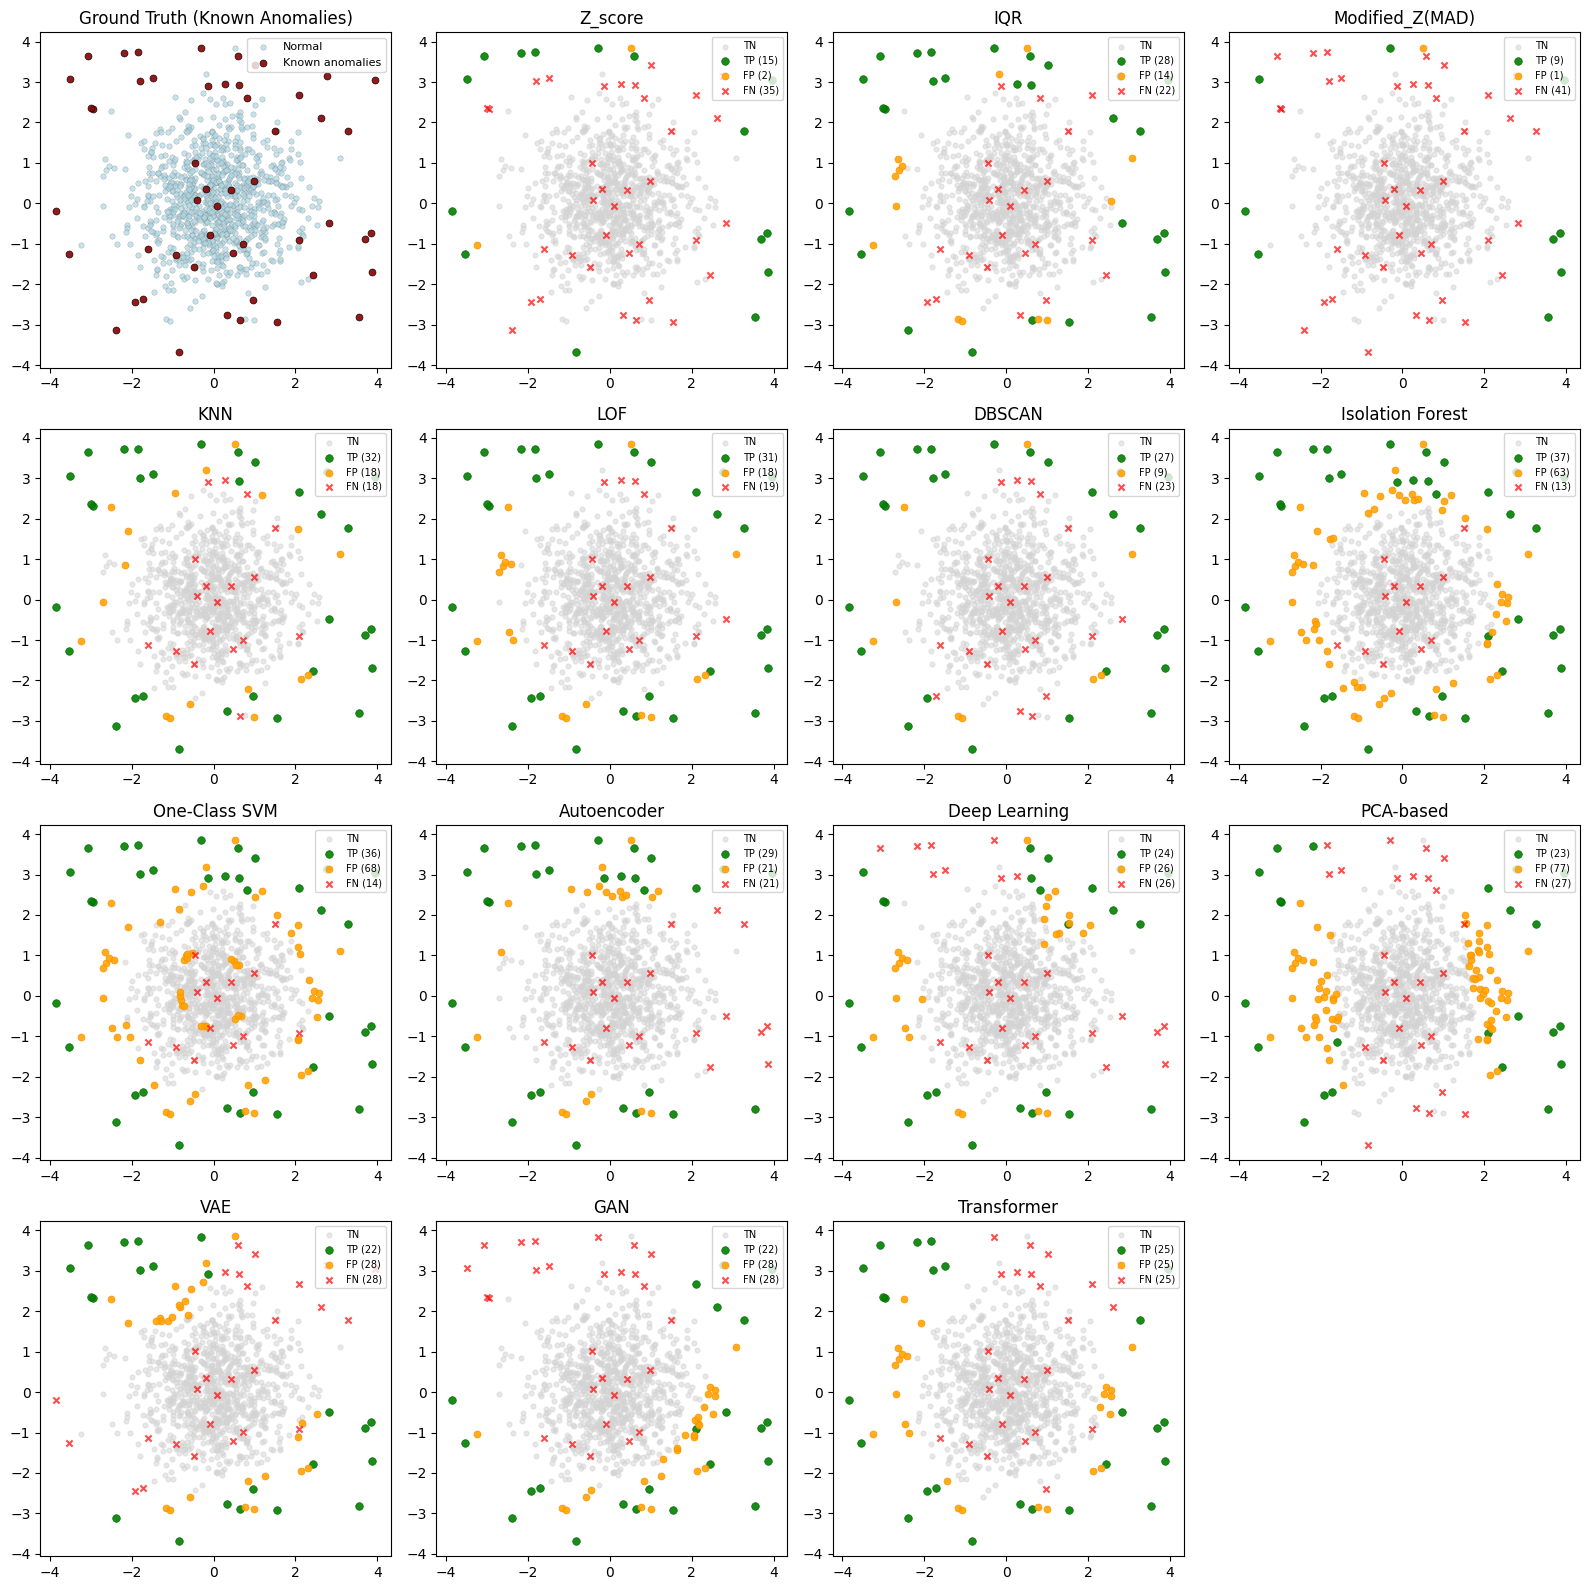

In [34]:
# Plot all methods: known anomalies, true positives (TP), false positives (FP)

y_true = df['is_anomaly'].astype(int).to_numpy()
methods_plot = [
    ("Z_score", statistical_anomalies), ("IQR", iqr_anomalies), ("Modified_Z(MAD)", mad_anomalies),
    ("KNN", knn_anomalies), ("LOF", lof_anomalies), ("DBSCAN", dbscan_anomalies),
    ("Isolation Forest", iso_anomalies), ("One-Class SVM", oc_svm_anomalies),
    ("Autoencoder", autoencoder_anomalies), ("Deep Learning", dl_anomalies),
    ("PCA-based", pca_anomalies), ("VAE", vae_anomalies), ("GAN", gan_anomalies),
    ("Transformer", transformer_anomalies),
]

n_methods = len(methods_plot) + 1  # +1 for ground truth
n_cols = 4
n_rows = (n_methods + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

# Panel 0: Ground truth (known anomalies)
normal_mask = df['is_anomaly'] == 0
anomaly_mask = df['is_anomaly'] == 1
axes[0].scatter(df[normal_mask]['feature_1'], df[normal_mask]['feature_2'],
                c='lightblue', s=15, alpha=0.7, label='Normal', edgecolors='gray', linewidths=0.3)
axes[0].scatter(df[anomaly_mask]['feature_1'], df[anomaly_mask]['feature_2'],
                c='darkred', s=25, alpha=0.9, label='Known anomalies', edgecolors='black', linewidths=0.5)
axes[0].set_title('Ground Truth (Known Anomalies)')
axes[0].legend(loc='upper right', fontsize=8)

# Panels 1+: Each method with TP, FP, TN, FN coloring
for idx, (name, pred_arr) in enumerate(methods_plot):
    ax = axes[idx + 1]
    y_pred = np.asarray(pred_arr).astype(int)
    tn_mask = (y_true == 0) & (y_pred == 0)
    tp_mask = (y_true == 1) & (y_pred == 1)
    fp_mask = (y_true == 0) & (y_pred == 1)
    fn_mask = (y_true == 1) & (y_pred == 0)
    ax.scatter(df[tn_mask]['feature_1'], df[tn_mask]['feature_2'],
               c='lightgray', s=12, alpha=0.5, label='TN')
    ax.scatter(df[tp_mask]['feature_1'], df[tp_mask]['feature_2'],
               c='green', s=30, alpha=0.9, label=f'TP ({tp_mask.sum()})', edgecolors='darkgreen', linewidths=0.5)
    ax.scatter(df[fp_mask]['feature_1'], df[fp_mask]['feature_2'],
               c='orange', s=25, alpha=0.9, label=f'FP ({fp_mask.sum()})', edgecolors='darkorange', linewidths=0.5)
    ax.scatter(df[fn_mask]['feature_1'], df[fn_mask]['feature_2'],
               c='red', s=20, alpha=0.7, label=f'FN ({fn_mask.sum()})', marker='x')
    ax.set_title(name)
    ax.legend(loc='upper right', fontsize=7)

for j in range(n_methods, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

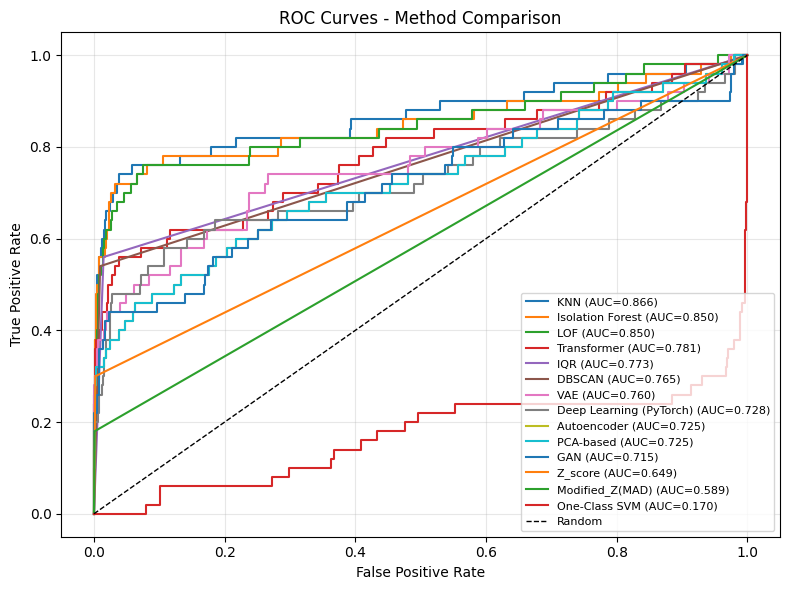

In [36]:
# 2. ROC curves for method comparison
from sklearn.metrics import roc_curve, auc

y_true = df['is_anomaly'].astype(int).to_numpy()

# Build anomaly scores (higher = more anomalous). Use binary preds where no scores available.
def get_scores(name, pred):
    pred = np.asarray(pred).astype(float)
    try:
        if name == "Isolation Forest":
            return -iso_forest.decision_function(df[['feature_1', 'feature_2']]).flatten()
        elif name == "LOF": return -lof.negative_outlier_factor_.flatten()
        elif name == "One-Class SVM":
            Xs = StandardScaler().fit_transform(df[['feature_1', 'feature_2']].values)
            return oc_svm.decision_function(Xs).flatten()
        elif name == "KNN": return mean_distances
        elif name == "Autoencoder": return reconstruction_error
        elif name == "Deep Learning (PyTorch)": return dl_reconstruction_error
        elif name == "PCA-based": return pca_reconstruction_error
        elif name == "VAE": return mse_per
        elif name == "GAN": return dists
        elif name == "Transformer": return transformer_error
    except NameError:
        pass
    return pred

# Compute AUC for each method, sort by AUC descending (best first)
method_aucs = []
for name in all_methods:
    pred = all_methods[name]
    scores = get_scores(name, pred)
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    method_aucs.append((name, fpr, tpr, roc_auc))
method_aucs.sort(key=lambda x: x[3], reverse=True)

fig, ax = plt.subplots(figsize=(8, 6))
for name, fpr, tpr, roc_auc in method_aucs:
    ax.plot(fpr, tpr, lw=1.5, label=f'{name} (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Method Comparison')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

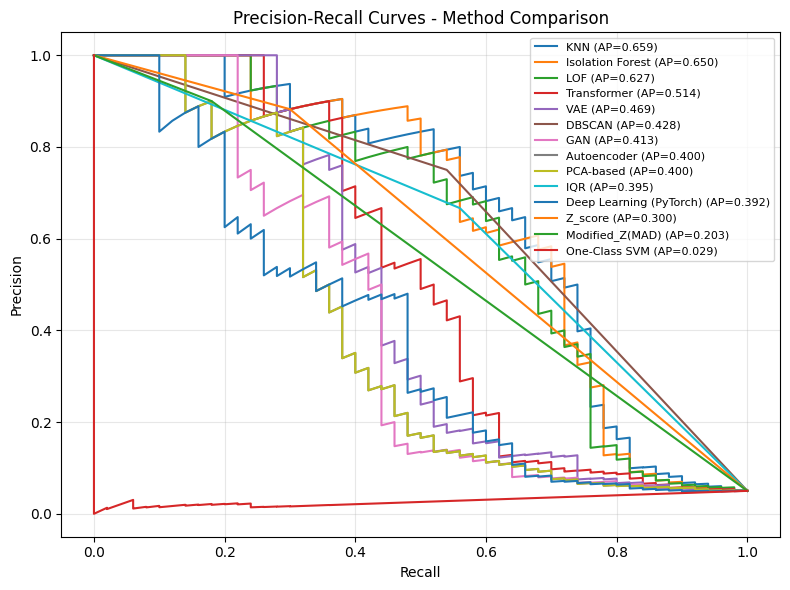

In [38]:
# 3. Precision-Recall curves for method comparison
from sklearn.metrics import precision_recall_curve, average_precision_score

def get_scores_pr(name, pred):
    pred = np.asarray(pred).astype(float)
    try:
        if name == "Isolation Forest":
            return -iso_forest.decision_function(df[['feature_1', 'feature_2']]).flatten()
        elif name == "LOF":
            return -lof.negative_outlier_factor_.flatten()
        elif name == "One-Class SVM":
            Xs = StandardScaler().fit_transform(df[['feature_1', 'feature_2']].values)
            return oc_svm.decision_function(Xs).flatten()
        elif name == "KNN":
            return mean_distances
        elif name == "Autoencoder":
            return reconstruction_error
        elif name == "Deep Learning (PyTorch)":
            return dl_reconstruction_error
        elif name == "PCA-based":
            return pca_reconstruction_error
        elif name == "VAE":
            return mse_per
        elif name == "GAN":
            return dists
        elif name == "Transformer":
            return transformer_error
    except NameError:
        pass
    return pred

# Compute AP for each method, sort by AP descending (best first)
method_aps = []
for name in all_methods:
    pred = all_methods[name]
    scores = get_scores_pr(name, pred)
    precision, recall, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)
    method_aps.append((name, recall, precision, ap))
method_aps.sort(key=lambda x: x[3], reverse=True)

fig, ax = plt.subplots(figsize=(8, 6))
for name, recall, precision, ap in method_aps:
    ax.plot(recall, precision, lw=1.5, label=f'{name} (AP={ap:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves - Method Comparison')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

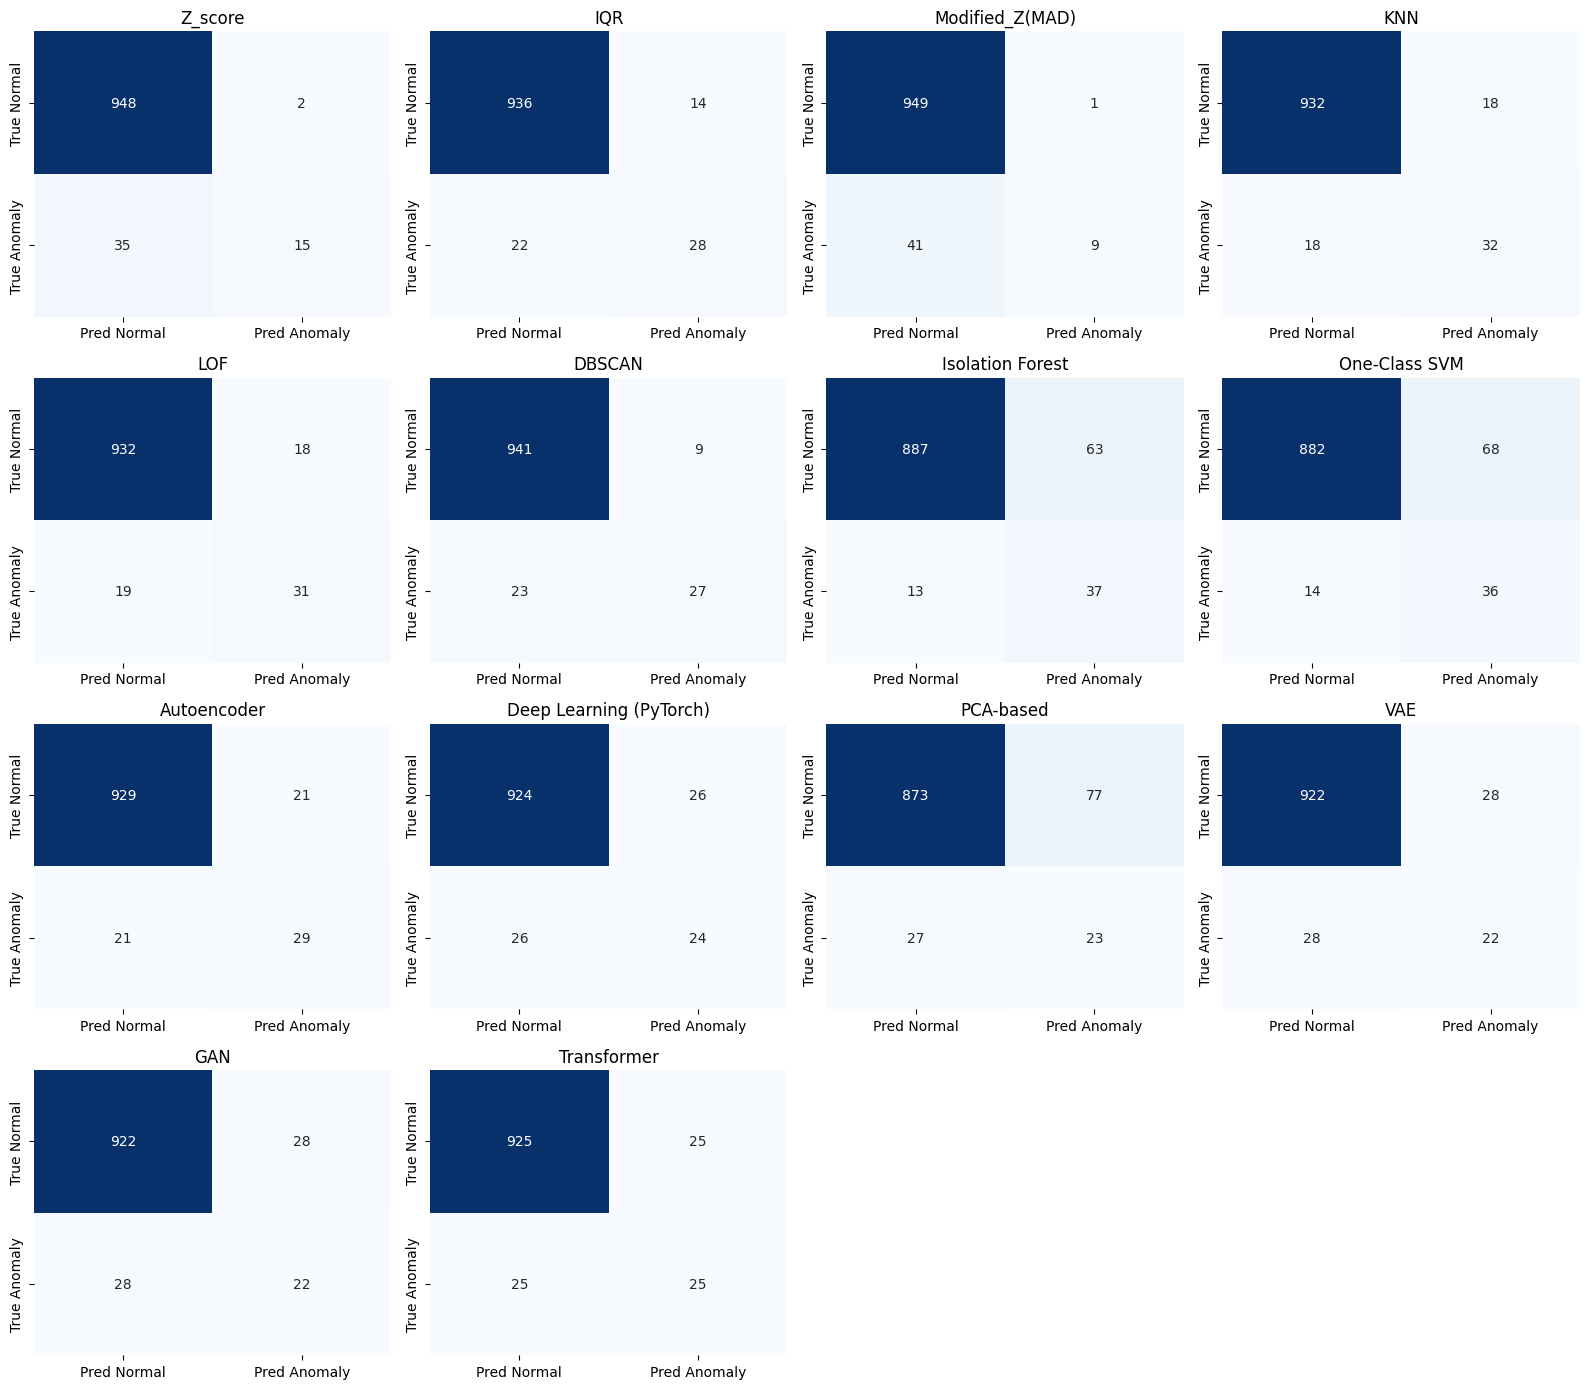

In [39]:
# 4. Confusion matrices for all methods
from sklearn.metrics import confusion_matrix
import seaborn as sns

n_m = len(all_methods)
n_cols = 4
n_rows = (n_m + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = np.array(axes).flatten()

for idx, (name, pred) in enumerate(all_methods.items()):
    ax = axes[idx]
    y_pred = np.asarray(pred).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum()  # proportional (0-1)
    annot = np.array([[f'{v:.1%}' for v in row] for row in cm_pct])
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues', ax=ax, cbar=False,
                vmin=0, vmax=1, xticklabels=['Pred Normal', 'Pred Anomaly'],
                yticklabels=['True Normal', 'True Anomaly'])
    ax.set_title(name)
    ax.set_xlabel('')
    ax.set_ylabel('')

for j in range(n_m, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## Part 5: Reflection and Best Practices

### Step 1: Document Your Learning

**🎯 Critical Thinking Exercise:** Answer these questions to deepen your understanding and connect to real-world applications.

### Reflection Questions

**Consider these questions about your anomaly detection experience:**
1. Which method worked best for your dataset?
2. How did AI-enhanced methods compare to traditional approaches?
3. What challenges did you encounter?
4. How would you validate the results in a real-world scenario?

In [ ]:
# TODO: Reflect on your anomaly detection experience

# AI Prompt: "Help me think through these reflection questions. What would a data science manager want to know about my anomaly detection approach?"

### Step 2: Best Practices

### Best Practices for Anomaly Detection

**Key principles to follow:**
1. Always validate results with domain experts
2. Consider the business context when setting thresholds
3. Use multiple methods for robust detection
4. Continuously monitor and update models
5. Document your approach for reproducibility

In [ ]:
# TODO: Document best practices for anomaly detection

## Final Reflection: Connecting to Your Career

**🎯 Career Connection:** Anomaly detection skills are highly valued in:
- **Financial Services:** Fraud detection, risk management
- **Cybersecurity:** Intrusion detection, threat analysis  
- **Manufacturing:** Quality control, predictive maintenance
- **Healthcare:** Medical diagnosis, patient monitoring
- **E-commerce:** Recommendation systems, fraud prevention

### Metacognitive Learning Prompts
- **What did you learn about your own learning process?**
- **How would you apply this to a different domain?**
- **What connections do you see to other concepts?**
- **What questions do you still have?**

**Next Steps:** Try applying these techniques to a real dataset from your field of interest. Consider how you would explain your approach to a non-technical stakeholder.

### Transfer Applications
- **How would this work in healthcare?**
- **What would change if you had 10 times more data?**
- **How would you explain this to business executives?**

### Expert Thinking
- **What would an expert do differently?**
- **What assumptions are you making?**
- **How would you validate your approach?**